Load Data frame and convert Trip Start Timestamp to date time

In [1]:
import pandas as pd

df = pd.read_csv("data/taxi_pickups_area.csv")

x = pd.to_datetime(df['Trip Start Timestamp'])

df.drop(columns='Trip Start Timestamp', inplace=True)

Plot original and season + trend + residual components

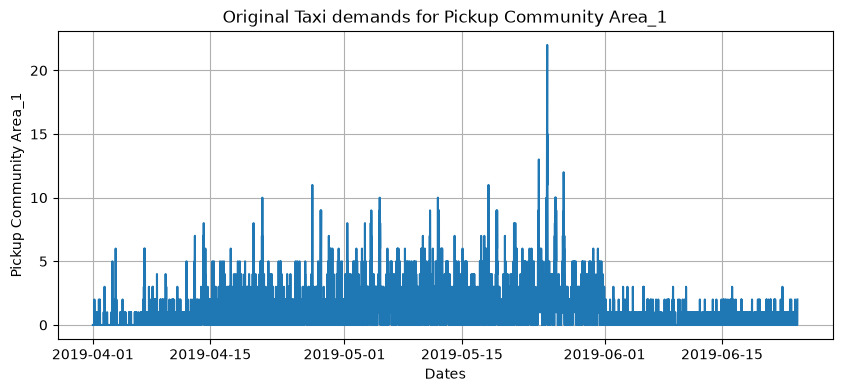

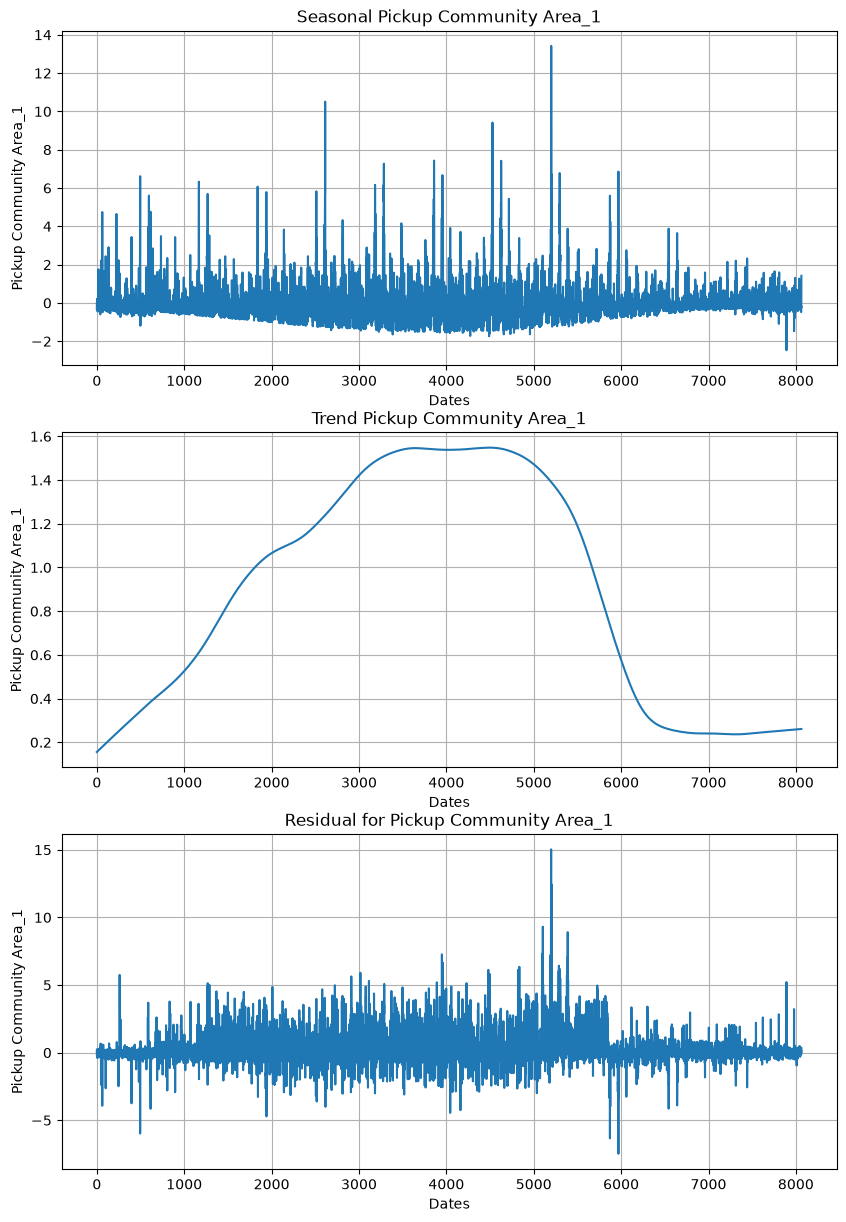

In [5]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL


plt.figure(figsize=(10, 4))
plt.plot(x, df['Pickup Community Area_1'])

plt.xlabel("Dates")
plt.ylabel("Pickup Community Area_1")
plt.title("Original Taxi demands for Pickup Community Area_1")
plt.grid(True)

stl = STL(df['Pickup Community Area_1'], robust=True, period=672)

result = stl.fit()

seasonal, trend, resid = result.seasonal, result.trend, result.resid

plt.figure(figsize=(10, 20))

plt.subplot(4,1,1)
plt.plot(seasonal)
plt.xlabel("Dates")
plt.ylabel("Pickup Community Area_1")
plt.title("Seasonal Pickup Community Area_1")
plt.grid(True)

plt.subplot(4,1,2)
plt.plot(trend)
plt.xlabel("Dates")
plt.ylabel("Pickup Community Area_1")
plt.title("Trend Pickup Community Area_1")
plt.grid(True)


plt.subplot(4,1,3)
plt.plot(resid)
plt.xlabel("Dates")
plt.ylabel("Pickup Community Area_1")
plt.title("Residual for Pickup Community Area_1")

plt.grid(True)
plt.show()

Anomaly Detection

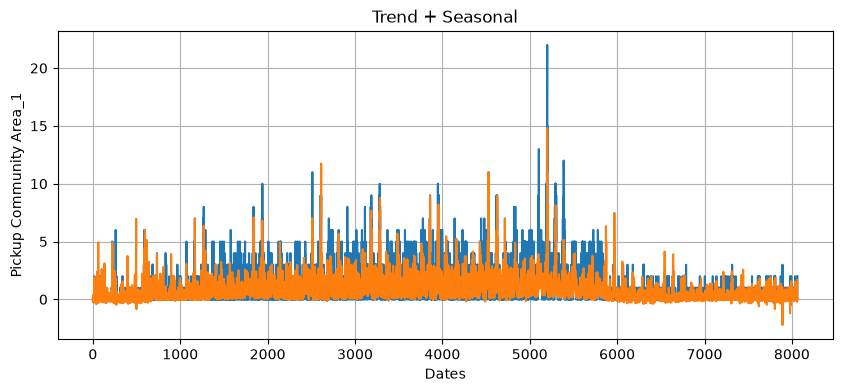

In [7]:
estimated = trend + seasonal

plt.figure(figsize=(10, 4))
plt.plot(df['Pickup Community Area_1'])
plt.plot(estimated)

plt.xlabel("Dates")
plt.ylabel("Pickup Community Area_1")
plt.title("Original + estimated")
plt.grid(True)

(0.0, 8000.0)

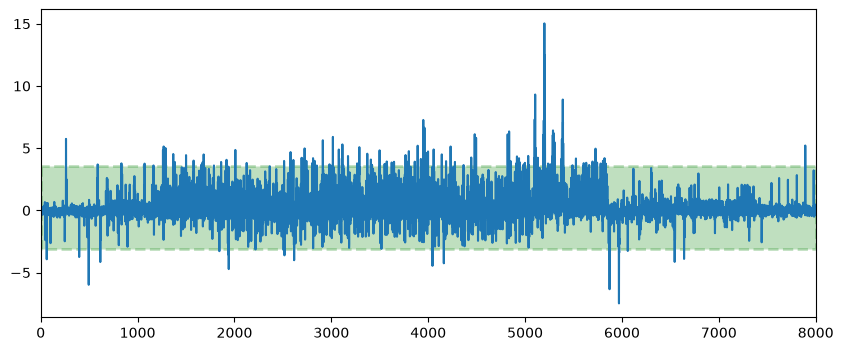

In [14]:

resid_m = resid.mean()
resid_dv = resid.std()


lower = resid_m - (3 * resid_dv) 
upper = resid_m + (3 * resid_dv)

plt.figure(figsize=(10, 4))
plt.plot(resid)

plt.fill_between([0, 8000], lower, upper, color='g', alpha=0.25, linestyle='--', linewidth=2)
plt.xlim(0, 8000)
##

Anomalies for Pickup Community Area_1

In [23]:
anomalies = df['Pickup Community Area_1'][(resid < lower) | (resid > upper)]
anomalies

62      1.0
261     6.0
397     0.0
494     0.0
495     0.0
       ... 
5971    1.0
6060    0.0
6544    0.0
6641    0.0
7892    3.0
Name: Pickup Community Area_1, Length: 181, dtype: float64